# Data Driven Analytics Summative 1 - EDA #

## Importing Data ##

In [1]:
# Importing libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Loading the dataset
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df = dataset["train"].to_pandas()

# Verifying the dataset has imported correctly
df.head()

#Code debugging was assisted by Microsoft Copilot (Microsoft, 2026) to resolve dataset 
#loading issues as the KaggleHub integration was not functioning as expected. 

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


## Data Cleaning ##

In order for analysis to be of high-quality and provide accurate analysis, it must first be prepared and cleaned. Thorough data preparation improves the performance of machine learning algorithms we apply to the data, improving the interpretability of the data and reducing the computational cost of running any program as processing time decreases and less resources are required. Gritsch, Tick and Rosenberger (2025) argue that is especially true for large datasets, like the one we are using here. The benefits explored by these authors is also agreed by Hosseinzaeh et al. (2021) where they argue that cleansing of the data is vital for trustworthy analytics.

The data cleansing pipeline below is inspired by article by Babu and Vijayakumar (2025) which describes the order of operations for data cleansing to ensure data preparedness.

In [3]:
# Looking at the size of the dataset
df.shape

(61765, 16)

In [4]:
# Understanding the dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  object 
 1   body      61763 non-null  object 
 2   answer    48576 non-null  object 
 3   type      48587 non-null  object 
 4   queue     61765 non-null  object 
 5   priority  61765 non-null  object 
 6   language  61765 non-null  object 
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  object 
 9   tag_2     48528 non-null  object 
 10  tag_3     48356 non-null  object 
 11  tag_4     43990 non-null  object 
 12  tag_5     27636 non-null  object 
 13  tag_6     13225 non-null  object 
 14  tag_7     5968 non-null   object 
 15  tag_8     2472 non-null   object 
dtypes: float64(1), object(15)
memory usage: 7.5+ MB


In [5]:
# Checking for null values
df.isnull().any()

subject      True
body         True
answer       True
type         True
queue       False
priority    False
language    False
version      True
tag_1        True
tag_2        True
tag_3        True
tag_4        True
tag_5        True
tag_6        True
tag_7        True
tag_8        True
dtype: bool

While there are null values within all of the tag variables, I will not be addressing any null values here as they are not compulsory components in each support ticket. As such, I will just be focusing on the 4 fields that need to be present in any further analysis: subject, body, answer and type.

In [6]:
# Examining columns with null values that need to be addressed
cols_to_check = ["subject", "body", "answer", "type"]

# Getting the number of rows with null values in the specified columns
rows_with_nulls = df[df[cols_to_check].isnull().any(axis=1)].shape[0]
total_rows = df.shape[0]

# Display the number of rows with null values and the total number of rows in the dataset
rows_with_nulls, total_rows

(18488, 61765)

As there is no way to accurately fill the null values with data, it is safer in this case to drop these rows so that any future analysis is not skewed.

In [7]:
# Dropping rows with null values in the specified columns
df_clean = df.dropna(subset=cols_to_check).copy()

In [8]:
# Verifying the size of the cleaned dataset
df_clean.shape

(43277, 16)

In [9]:
# Checking for remaining null values after cleaning
df_clean[cols_to_check].isnull().sum()

subject    0
body       0
answer     0
type       0
dtype: int64

As there are now no null values in the dataset that could casue issues, the next step is to check for duplicated values in the data. None are found so we move onto checking the datatypes of the data.

In [10]:
# Checking for duplicated records that could skew analysis
df_clean.duplicated(subset=None).any().sum()

0

In [11]:
# Checking the data types of the columns to ensure they are appropriate for analysis
df_clean.dtypes

subject      object
body         object
answer       object
type         object
queue        object
priority     object
language     object
version     float64
tag_1        object
tag_2        object
tag_3        object
tag_4        object
tag_5        object
tag_6        object
tag_7        object
tag_8        object
dtype: object

This reveals that most of the datatypes are stated as being objects, this is default for any variables that cannot be easily defined, for example, it is clear that version should be a float as all values are numerical. The other columns are more difficult to define, which is expected given the unstructured nature of the data. Having the datatypes set as object does not limit any of the Exploratory Data Analysis required for this assignment. If the data were left as it is, it could cause errors during processes like PCA, however as the data will be transformed prior to this step, changing the datatypes is unnecessary at this stage.

The last optional step within the data cleansing is to remove the German records. While there is nothing wrong with these records, adding additional languages adds additional complexity to future analysis like sentiment analysis, feature analysis or topic modelling as non-English tickets may require translation prior to these steps. As the language of the ticket does not impact the tagging that has been applied to the ticket (all in English), these records have been kept for the EDA below, however the code to remove them is retained, in case it is needed in future. Keeping these records improves the quality of the EDA below as there are more records available for analysis.

If translation was to be attempted, a suitable product developed by my company is available and would reduce the financial cost associated with the framework, as well as providing a use case that we could present to customers, driving additional sales. Other competitors do also produce similar software, for example, Microsoft's Azure AI Translator or Amazon's AWS Translate, both of which scale well to enterprise sized data like this.

In [12]:
# Removing the German lanaguage records
#df_clean = df_clean[df_clean["language"] == "en"]
#df_clean.shape

## Distribution Analysis ##

Now that the data is ready for EDA, the first step is to understand the distribution of the data. This is key as it allows us to understand how our data is spread and ensures we have collected a large enough sample size to represent the entire population of the company's customers. The concept of displaying distributions early in the EDA pipeline is backed by academic literature, the well regarded book by John Tukey (1977) states that a visual summary of the data should be the first visualisation created. This is built by Unwin (2015) who states that a count-based visualisation should be the first visualisation created, supporting the idea that a count plot (or similar) should form the initial visualisation. By doing so we can validate the data cleansing we have carried out as well as reveal categories for further exploration. In the code below we create pie charts of the three categorical variables as this is the most compact way to display large amounts of distribution data.

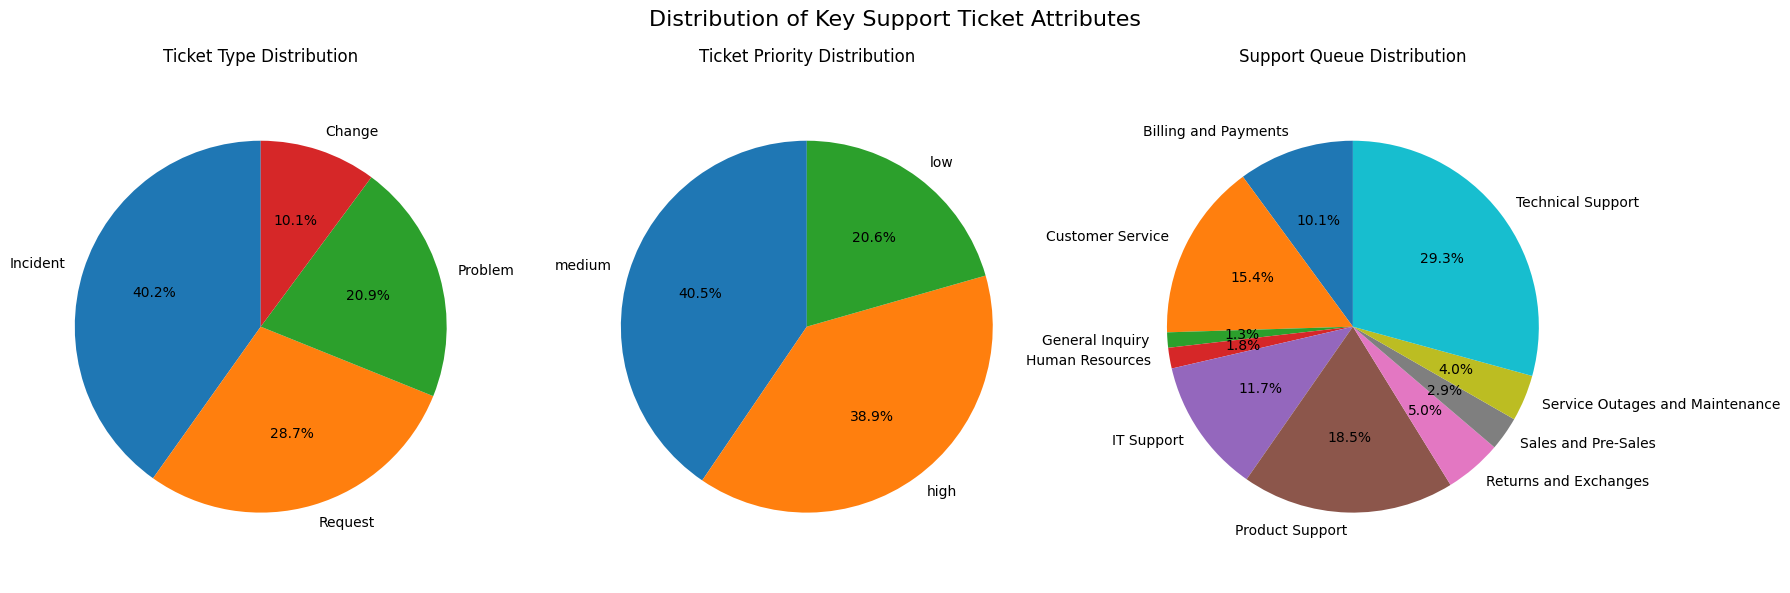

In [13]:
# Plotting the distribution of key categorical variables: 'type', 'priority', and 'queue'
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Ticket Type
type_counts = df_clean["type"].value_counts()
axes[0].pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title("Ticket Type Distribution")
axes[0].axis("equal")

# Priority
priority_counts = df_clean["priority"].value_counts()
axes[1].pie(
    priority_counts,
    labels=priority_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title("Ticket Priority Distribution")
axes[1].axis("equal")

# Queue
queue_counts = df_clean["queue"].value_counts().sort_index()
axes[2].pie(
    queue_counts,
    labels=queue_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[2].set_title("Support Queue Distribution")
axes[2].axis("equal")

# Displating the plots
plt.suptitle("Distribution of Key Support Ticket Attributes", fontsize=16)
plt.tight_layout()
plt.show()

Looking at the pie charts above we can see that we have a good sample of data for each unique value, suggesting that we are mimicking real customer behaviours. For ticket types we see that the majority of the tickets are raised when something is wrong (incident or problem). This reflects real world behaviours and is the type of data we expect to see in a support ticket database.

We see a fairly even distribution of the ticket priorities, with a slight slant towards the more severe end of the scale, perhaps reflecting the customers reluctance to rate their issue as low impact for fear of longer response times?

Lastly we see the distribution of which departments the tickets are triaged to. Naturally many of them are directed to technical or product support (a cummulative 47.8% of tickets), but we do also see a number of tickets directed towards the 'sales' departments e.g. 'Sales and Presales' and 'Billing and Payments'. 

The next step is to look at the tags. While not so cleanly formated, each ticket contains up to 8 tags categorising the ticket further. With some additional manipulation we are able to get a count of how many unique tags there are and how many times each one is referenced.

In [14]:
# Getting a count of each unique tag across all tag columns
tag_cols = [col for col in df_clean.columns if col.startswith("tag_")]

all_tags = (df_clean[tag_cols].stack().dropna())

tag_counts = all_tags.value_counts()
tag_counts.shape[0]

2020

From the code above we can see that there are 2020 unique tags across the remaining 43277 tickets. Visualising all of these would make it difficult to draw any meaningful conclusions about what most customers are concerned about. In the code below we focus our attention on the 20 most common tags.

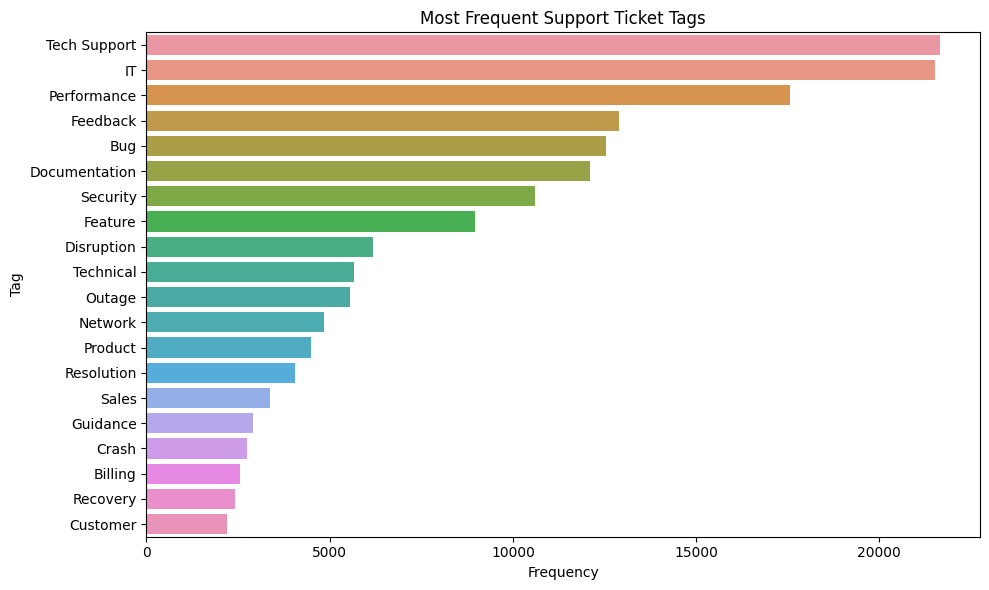

In [15]:
# Select top N tags
top_n = 20
top_tags = tag_counts.head(top_n)

# Bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_tags.values,
    y=top_tags.index,
    orient="h"
)

# Display plot
plt.title("Most Frequent Support Ticket Tags")
plt.xlabel("Frequency")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

Looking at the tag analysis above we can see it represents a similar story to the Support Queue distribution we see above, more than 20000 tickets require some form of technical support, with 4 out of the top 5 tags suggesting tickets being raised in response to a negative experience with the product. This reaffirms the idea that support tickets can give valuable insight into where customers would find most value with enhancements and fixes, validating the purpose of this project.

In [25]:
pd.crosstab(df_clean["type"], df_clean["priority"], normalize="all")


priority,high,low,medium
type,,,
Change,0.039490,0.021258,0.040691
Incident,0.173395,0.074867,0.153430
Problem,0.079511,0.043372,0.086605
Request,0.096980,0.066201,0.124200


The dataset shows that incident tickets dominate overall ticket volume (40% of all tickets) and are disproportionately associated with high‑priority classifications, whereas requests are more concentrated in medium‑priority categories.

### Correlations 

The next step is to calculate the correlations between the categorical variables. In the code below categorical variables are one‑hot encoded using pandas get_dummies function (pandas, 2026) to enable correlation analysis and maintain interpretability during exploratory analysis. The pandas function is used instead Sklearn's OneHotEncoder() function as it allows us to retain easily understadable variable names by default, instead of having to extract the feature names and perform additional manipulation steps to do the same thing.

If any ML algorithms will be used encoding categorical variables is essential as many supervised algorithms operate on vectors of numbers. Without encoding, the model cannot compute distances, gradients, or inner products (Hancock and Khoshgoftaar, 2020) limiting or even prohibitng any machine learning that can be performed.

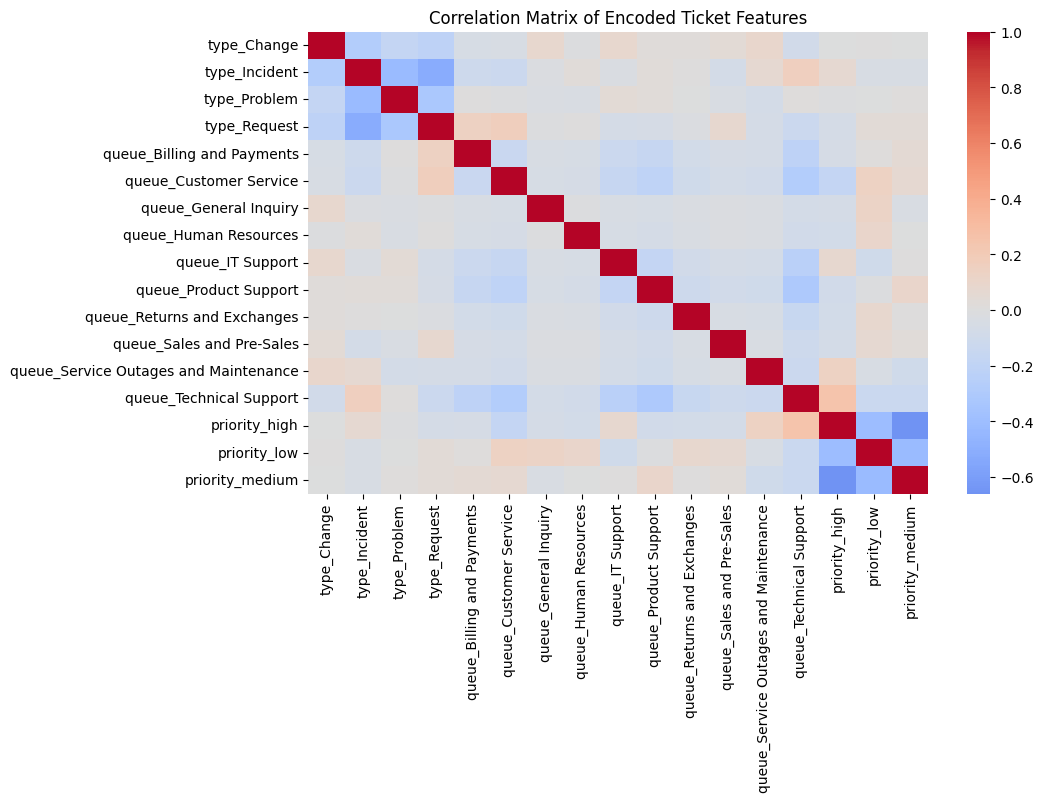

In [17]:
# Setting categorical columns for correlation analysis
structured_cols = ["type", "queue", "priority"]
df_structured = df_clean[structured_cols]
df_encoded = pd.get_dummies(df_structured, drop_first=False)

# Creating a correlation matrix for the encoded features
corr_matrix = df_encoded.corr()

# Correlation heatmap visualisation
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Encoded Ticket Features")
plt.show()


Weak correlations between each type (e.g. queue and type) show us that each variable captures a different aspect of the service process and that each column in the dataset is recording something distinct and no group is dominating. This is good as it shows us that there is no data replication and that our dataset is multidimensional.

The high redundancy within the groups (type, queue, priority) shows us that the one shot encoding introduces linear dependance (Hastie, Tibshirani and Friedman, 2009) creating multicollinearity and artificial dimensional inflation, justifying PCA to allow us to identify latent patterns.

### Scaling

The next step is to scale the data. Scaling is key to perform during EDA and prior to any further modelling, to ensure each feature contributes proportionally and preventing larger variables dominating the dataset (Kalinina et al. 2025), preserving the quality of the insights obtained. 

In [18]:
# Scaling the encoded dataframe
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

PCA is sensitive to feature scale, standardisation ensures equal contribution of encoded features to variance estimation. In the code below Principal Component Analysis is applied to identify latent issue dimensions within the scaled feature space.

In [19]:
# Performing PCA on the scaled data
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Extracting the explained variance ratio for each principal component
explained_variance = pca.explained_variance_ratio_

# Creating a DataFrame to display the variance explained by each principal component
variance_df = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "Variance Explained": explained_variance,
    "Cumulative Variance": np.cumsum(explained_variance)
})

variance_df


,Component,Variance Explained,Cumulative Variance
0,1,1.229590e-01,0.122959
1,2,9.316085e-02,0.216120
2,3,8.707557e-02,0.303195
3,4,8.210988e-02,0.385305
4,5,7.738204e-02,0.462687
5,6,6.868702e-02,0.531374
6,7,6.632756e-02,0.597702
7,8,6.497008e-02,0.662672
8,9,6.188707e-02,0.724559
9,10,6.095825e-02,0.785517


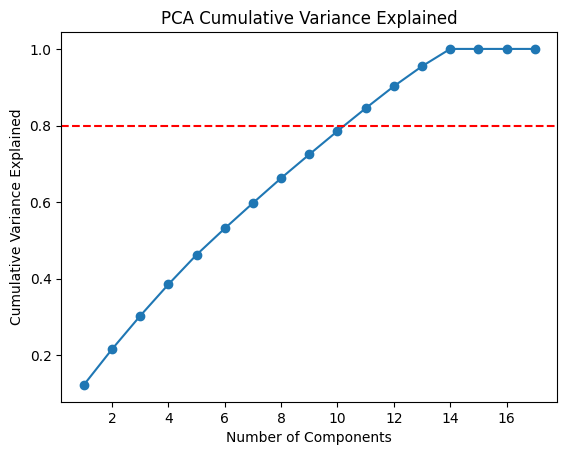

In [20]:
# Visualising the cumulative variance explained by the principal components to determine how many components to retain
plt.plot(variance_df["Component"], variance_df["Cumulative Variance"], marker="o")
plt.axhline(0.8, linestyle="--", color="red")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Cumulative Variance Explained")
plt.show()

Before looking at the results of the graph above, it is important to explore why the line is place at 0.8 of the Cummalative Variance Explained. While there is no set optimal threshold for where the line should be set, 80% variance is commonly used in academia and industry, we see this in Jolliffe (2002) where the author states that a 0.8 threshold allows the data to be "reasonably faithful" to the source material. Setting the value at 80% means that we retain a high level of meaningful data, without overfitting.

This graph shows us there is no single dominant component. We see that approximately 10-11 components explains 80% of the variance, therefore the effective dimensionality of the data after PCA is substantially lower than the raw encoded feature space, removing redundancy and making future processing more efficient. Using these 10-11 principal components going forward should be sufficient in retaining the majority of the information within the dataset based on this information.

Beyond 13 components we see dimishing returns so each new component is adding little value and is likely not worth the additional processing to include these.

Note: Literature search was enhanced using Copilot (Microsoft, 2026) to identify academic justification for the 80% threshold.

In [21]:
# Selecting the number of principal components that explain at least 80% of the variance
n_components = variance_df[variance_df["Cumulative Variance"] <= 0.8].shape[0]
X_reduced = X_pca[:, :n_components]

In this project principal components are retained up to the point where cumulative explained variance reached approximately 80%, ensuring substantial information preservation while avoiding unnecessary dimensional complexity, based on the standard practice as outlined by Jolliffe (2002).

In [22]:
# Creating a DataFrame to display the loadings of the original features on the principal components
loadings = pd.DataFrame(
    pca.components_,
    columns=df_encoded.columns,
    index=[f"PC{i+1}" for i in range(len(pca.components_))]
)

loadings

,type_Change,type_Incident,type_Problem,type_Request,queue_Billing and Payments,queue_Customer Service,queue_General Inquiry,queue_Human Resources,queue_IT Support,queue_Product Support,queue_Returns and Exchanges,queue_Sales and Pre-Sales,queue_Service Outages and Maintenance,queue_Technical Support,priority_high,priority_low,priority_medium
PC1,-0.030965,0.349951,-0.040082,-0.322403,-0.155514,-0.284298,-0.053753,-0.051583,0.048109,-0.085743,-0.061574,-0.110861,0.140578,0.406072,0.529061,-0.200295,-0.360606
PC2,-0.022931,0.400948,-0.011623,-0.408600,-0.134109,-0.166529,-0.071911,0.013776,0.045210,0.319456,0.020879,-0.080751,-0.063360,-0.022139,-0.315652,-0.300722,0.561178
PC3,-0.022474,0.436474,-0.327591,-0.163259,-0.161663,0.096437,0.200413,0.219016,-0.253355,0.044006,0.169808,0.037268,0.077642,-0.070991,-0.227658,0.575258,-0.247551
PC4,0.493582,-0.228958,0.339869,-0.386883,-0.162641,-0.159903,0.184618,-0.023288,0.323622,0.201232,0.101873,0.031676,0.152102,-0.331560,0.034072,0.173428,-0.176654
PC5,-0.360873,-0.096795,0.663295,-0.250849,-0.073179,0.089097,-0.020934,0.017148,-0.187156,-0.007322,0.047451,-0.117292,-0.355660,0.290981,-0.125497,0.244219,-0.076440
PC6,-0.146300,-0.057777,0.027846,0.135152,0.294597,-0.347189,-0.070624,-0.047335,-0.387201,0.703334,-0.126062,-0.034611,0.046259,-0.161235,0.138893,0.044692,-0.174769
PC7,-0.068146,-0.002723,0.003374,0.045379,-0.528468,0.604779,-0.191335,-0.162426,-0.028392,0.308193,-0.295008,-0.185446,0.155366,-0.134950,0.127188,-0.063380,-0.074151
PC8,0.371367,-0.205331,-0.079042,0.045759,-0.335529,-0.071141,0.255499,-0.201667,-0.422193,0.092020,-0.098544,0.423926,-0.100156,0.425699,-0.065495,-0.058736,0.113424
PC9,0.104264,-0.037999,0.092889,-0.111924,0.152599,0.146925,-0.100238,-0.390842,-0.422810,-0.142615,0.543795,-0.241771,0.435658,-0.015737,-0.007944,-0.092025,0.083669
PC10,-0.137014,-0.017199,-0.045319,0.150793,-0.333578,-0.133671,-0.505843,-0.021477,0.136706,0.118134,0.564515,0.406758,-0.185326,-0.077486,0.079671,0.006543,-0.084528


Looking more closely at this table, we see that for PC1, high positive values are seen for queue_technical_support (+0.403), priority_high (+0.531) and type_incident (+0.354) and negative loadings for type_request (-0.313) and priority_low (-0.185). This shows us that PC1 increases when the priority is high, the ticket includes technical support and involves incidents. We could interpret this as PC1 differentiating between a critical service issue e.g. software is down at an important time and a less urgent request, e.g. feature enhancements.

For PC2, we see high loadings for type_Incident (+0.390), priority_medium (+0.549) and queue_Product Support (+0.337), with similar to PC1, negative loadings for requests. Where this does differentiate is that it shows that the priority alone does not demonstrate the severity of the ticket, rather each element adds a layer of context.

For PC3, we see more focus on the routing and the underlying organisational context. There are high positive loadings for human resources (+0.224) and general enquiries (+0.211), showing us that the PCA is capturing the deeper structure of the dataset. Overall we can see that the PCA has been successful in creating meaningful distinctions and representing complex support interactions in a small number of dimensions.

## References

Babu, Y.S. and Vijayakumar, K. (2025) 'Data Cleansing and Preprocessing Automation in Python: An Efficient Pipeline Approach', *International Journal of Engineering Research and Science & Technology*, 21(4), pp 181-187 [Online]
Available at: https://ijerst.org/index.php/ijerst/article/view/1506/1356
(Accessed 10th April 2026)

Gritsch, C., Tick, A. and Rosenberger, P. (2025) 'Data Cleansing Methods for Big Data: A Systematic Review', *Proceedings of the 2025 IEEE 29th International Conference on Intelligent Engineering Systems (INES)*. 11th - 13th July 2025, Palermo.
Available at: https://ieeexplore.ieee.org/document/11078189?utm_source=copilot.com
(Accessed 10th April 2026)

Hancock, J.T. and Khoshgoftaar, T.M. (2020) ‘Survey on categorical data for neural networks’, *Journal of Big Data*, 7, Article 28 [Online]
Available at: https://link.springer.com/article/10.1186/s40537-020-00305-w
(Accessed 10th April 2026)

Hastie, T., Tibshirani R. and Friedman J. (2009) 'The Elements of Statistical Learning', *Data Mining, Inference, and Prediction*, Second Edition. 
Available at: https://link.springer.com/book/10.1007/978-0-387-84858-7
(Accessed 10th April 2026)

Hosseinzadeh, M., Azhir, E., Ahmed, O.H., Ghafour, M.Y., Ahmed, S.H., Rahmani, A.M. and Vo, B. (2023) 'Data Cleansing Mechanisms and Approaches for Big Data Analytics: A Systematic Study', *Journal of Ambient Intelligence and Humanized Compututing*, 14, 99–111. 
Available at: https://doi.org/10.1007/s12652-021-03590-2 
(Accessed 10th April 2026)

Jolliffe, I.T (2002) 'Principal Components Analysis', 2nd Edition, 
Available at: http://cda.psych.uiuc.edu/statistical_learning_course/Jolliffe%20I.%20Principal%20Component%20Analysis%20%282ed.,%20Springer,%202002%29%28518s%29_MVsa_.pdf
(Accessed 10th April 2026)

Kalinina, I., Gozhyj, A., Bidtuk, P., Gozhyi, V., Korobchynskyi, M. and Nadraga, V. (2025) ‘A Systematic Approach to Data Normalization and Standardization in Machine Learning Problems’, In Babichev, S. and Lyvtynenko, V, *Lecture Notes in Data Engineering, Computational Intelligence, and Decision-Making*, Volume 2, pp 206-219 [Online]
Available at: https://link.springer.com/chapter/10.1007/978-3-031-88483-2_11
(Accessed 10th April 2026)

pandas (2026) pandas.get_dummies [Online]
Available at: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html
(Accessed 10th April 2026)
